# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?


A penalty is part of regularization in which when you try to minimize error by adding a penality to the alpha and error. The larger the coefficient gets the larger the penalty.  Adding a penalty to mean squared error causes the model to stop using very large coefficients. Without a penalty, the model may fit the training data extremely close.  The penalty term increases as the coefficients grow, so the model is “pushed” to keep them small. This leads to simpler, smoother models that are less sensitive to random fluctuations in the data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization adds a penalty to the model’s complexity. Low penalty means the model fits closely with the data and suggets a low bias but high variance. If there is a high penalty means the coefficients shrink towards 0 and there would be a high bias and low variance.    


3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge can smoothly shrink the coefficients towards zero but never removes a variables completely. The ridge regression also keeps all the predictors in the model. The LASSO regression method has points of non-differentiability at 0. The LASSO method zeros out on the corners. The LASSO shrinks the coefficients. Ridge typically performs better but the LASSO test provides more interpretable results. The answers are different because ridge will have more predictors as it never removes variables. The answers for Ridge handles multiconlinearity better as well due to these extra variables. Lasso is better when working with fewer variables as the results will be sparse so the results that are made will be better.


4. How do we typically scale variables for use in regularized regression? Why?

We can scale variable with standardization/normalization; based on the z score formula. We need scale variables in regularized regression because then penalty's might have too strong of an impact on the model or there could be shrinkage or the model.


5. How is the penalty $\alpha$ typically selected?

To do this we have to cross-validate. We first pick a grid of a values. For each K value we use k- fold cross validation which includes picking the coefficients to minimize MSE(b hat) + ab^2 on the training fold and Evaluate MSE(b hat) on the folds. Then you pick a median/mean value for the MSE(b hat) across the grid. This process will generate the paths of the coefficients so you can see how variables the coefficients are. Each a is basically evaluated based on the folds to minimize validation error.



6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No we do not include the term in the cross validation. The goal of cross-validation is to estimate prediction error on the new data whereas the penalty is for training, Including the penalty will lead to bias towards simple models.




**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

After fitting a linear regression model of Mileage_Run and Age, the coefficient on the interaction term is negative. The effect of mileage on price becomes more negative as the age of the car increases.


3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?

All the features was selected therefore the proportion was zero to begine with. This means that all the features are valuable.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Based on the table, there seems to be an increase in magnitude many times but there was not a change in sign. This could suggest a strong correlation among polynomial features. The sign not being changes could suggest the direction of relationships is consistent across models.

In [1]:
#1
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Cloning into 'get_data'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 32 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 17.04 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


In [2]:
df = pd.read_csv('/content/data/cars_hw.csv')

df['Age'] = 2026 - df['Make_Year']
df.head()

X = df[["Mileage_Run", "Age"]]
y = df["Price"]


#use PolynomialFeatures to create a third degree expansion
import seaborn as sns
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print(feature_names)


#(b) use StandardScaler to  𝑧 -score normalize them.

X_scaled = scaler.fit_transform(X_poly)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

coefs = dict(zip(feature_names, model.coef_))

coefs["Mileage_Run Age"]



['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2']


np.float64(-225249.69910497972)

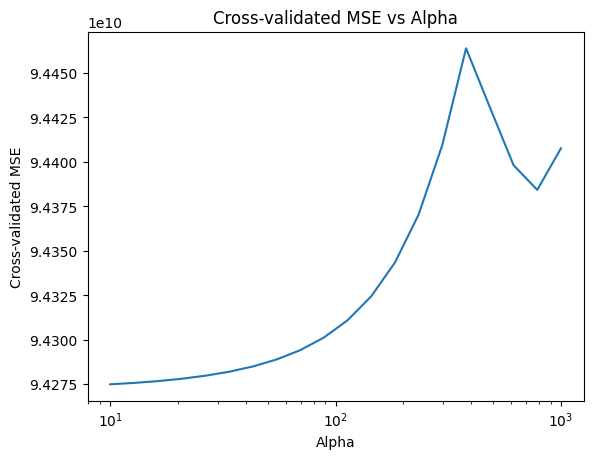

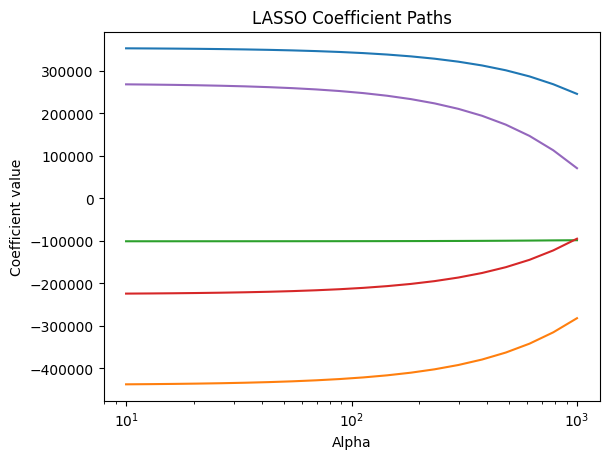

{'Mileage_Run': np.float64(352927.95785137656), 'Age': np.float64(-437271.05301773926), 'Mileage_Run^2': np.float64(-100841.91657890966), 'Mileage_Run Age': np.float64(-223933.47047384328), 'Age^2': np.float64(268223.55816812854)}
0.0
           Feature            OLS          LASSO
0      Mileage_Run  245755.439344  352927.957851
1              Age -281776.692796 -437271.053018
2    Mileage_Run^2  -98384.213907 -100841.916579
3  Mileage_Run Age  -94786.676307 -223933.470474
4            Age^2   71020.538722  268223.558168


In [4]:
#3, 4, 5
#LASSO with 20-fold Cross Validation
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)


#Plot cross-validated MSE by α

import matplotlib.pyplot as plt
import numpy as np

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Cross-validated MSE vs Alpha")
plt.show()

# Plot coefficient paths by  α

from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

selected = dict(zip(feature_names, lasso.coef_))
print(selected)

num_zero = np.sum(lasso.coef_ == 0)
total = len(lasso.coef_)

num_zero / total


ols_coefs = model.coef_
lasso_coefs = lasso.coef_

comparison = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols_coefs,
    "LASSO": lasso_coefs
})
print(num_zero / total)
print(comparison)

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

Some of the results do seem counterintutive. For example, age = −0.54, but age^2 = +0.59 and ejection_fraction = −0.84, but ejection_fraction^2 = +0.62. These results are likely due to multicollinearity. Since age and age squared are polynomials and related, they will have a stronger correlation. However, interaction terms will natrually suggest dependence between variables.  The inclusion of higher-order powers or interaction helps with these contradictions because the contradicting signs suggest that age has a non-linear pattern or relationship. With this explanation we know how age and ejection act with risk. Low ages might show risk decreasing but high ages show risk increasing rapadily rather than at a constant linear rate.



3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

The LASSO selected many features, some of which include ejection fraction, age, and many more. 0.2631578947368421 is the proportion set to 0. Coefficients increasing in magnitude include serum creatinine and anaemia. This happens because LASSO removes competing correlated variables. Some coefficients also change such as sign age × ejection_fraction = +0.079 -> 0
diabetes =  −0.031 -> 0. These sign changes happen because the LASSO thinks these variables are not useful so they are set to 0. Sign patterns make more sense from LASSO because coefficients are smaller and more stable and irrelevant variables are removed. Bias-variance trade-off shows that LASSO only has a slightly high bias and lower variance while linear regression has low bias and high variance. Linear regression as a result has large coefficients and unstable signs and LASSO shrinks coefficients and has more stability.

In [5]:
import pandas as pd
df = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


ejection_fraction                    -0.838863
ejection_fraction^2                   0.623213
age^2                                 0.587504
age                                  -0.541672
serum_creatinine^2                   -0.187895
ejection_fraction serum_creatinine    0.131684
diabetes smoking                      0.127223
high_blood_pressure smoking           0.105303
smoking                              -0.091274
age serum_creatinine                  0.090554
diabetes high_blood_pressure          0.087589
serum_creatinine                      0.084453
age ejection_fraction                 0.079182
anaemia smoking                       0.064392
anaemia diabetes                      0.040973
dtype: float64
Best alpha: 0.002592943797404667


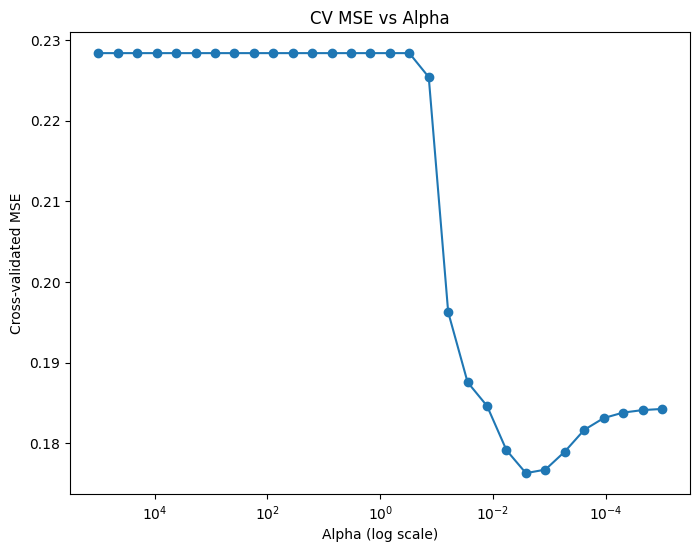

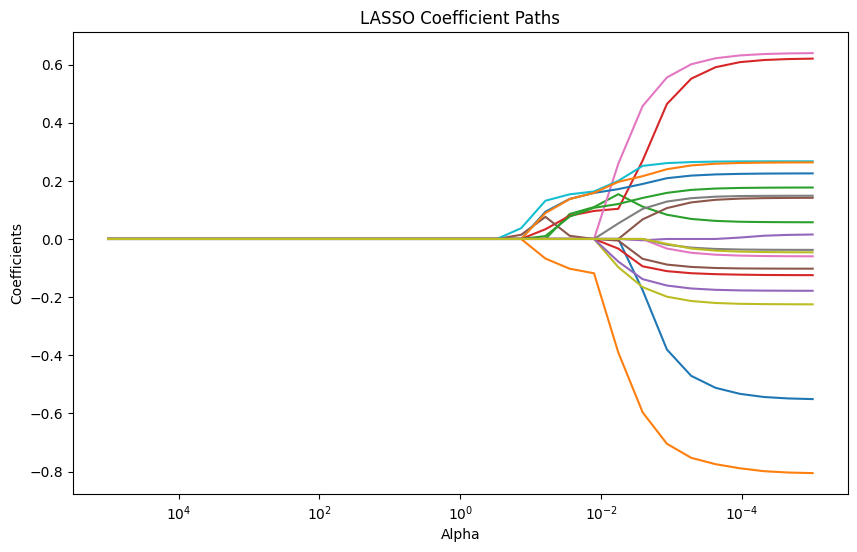

Selected features:
ejection_fraction                    -0.587841
ejection_fraction^2                   0.445627
age^2                                 0.192968
serum_creatinine^2                   -0.123124
serum_creatinine                      0.111837
age                                  -0.091032
ejection_fraction serum_creatinine    0.088343
diabetes high_blood_pressure          0.069571
high_blood_pressure smoking           0.062845
diabetes smoking                      0.047954
age serum_creatinine                  0.034865
anaemia                               0.029257
smoking                              -0.029255
high_blood_pressure                   0.008843
dtype: float64
Proportion of coefficients set to zero: 0.2631578947368421
                                      Linear     LASSO  Sign Change
ejection_fraction                  -0.838863 -0.587841        False
ejection_fraction^2                 0.623213  0.445627        False
age^2                               0.587504 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.model_selection import train_test_split


y = df["DEATH_EVENT"]

# Continuous variables
cont_vars = ["age", "ejection_fraction", "serum_creatinine"]

# Categorical (binary) variables
cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(df[cont_vars])
feature_names = poly.get_feature_names_out(cont_vars)

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_poly)

poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_cat_interact = poly_interact.fit_transform(df[cat_vars])

cat_feature_names = poly_interact.get_feature_names_out(cat_vars)

X = np.hstack([X_cont_scaled, X_cat_interact])

feature_names = list(feature_names) + list(cat_feature_names)

linreg = LinearRegression()
linreg.fit(X, y)

linreg_coefs = pd.Series(linreg.coef_, index=feature_names)

# View coefficients
print(linreg_coefs.sort_values(key=abs, ascending=False).head(15))

alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso_cv.fit(X, y)

best_alpha = lasso_cv.alpha_
print("Best alpha:", best_alpha)

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8,6))
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs Alpha")
plt.gca().invert_xaxis()
plt.show()

alphas_lasso, coefs_lasso, _ = lasso_path(X, y, alphas=alphas)

plt.figure(figsize=(10,6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

# Non-zero coefficients
selected = lasso_coefs[lasso_coefs != 0]

print("Selected features:")
print(selected.sort_values(key=abs, ascending=False))

# Proportion zero
prop_zero = np.mean(lasso_coefs == 0)
print("Proportion of coefficients set to zero:", prop_zero)


comparison = pd.DataFrame({
    "Linear": linreg_coefs,
    "LASSO": lasso_coefs
})

# Check sign changes
comparison["Sign Change"] = np.sign(comparison["Linear"]) != np.sign(comparison["LASSO"])

print(comparison.sort_values(by="LASSO", key=abs, ascending=False).head(20))



**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?

The denominator increases as a increases. So as a increases b1 decreases. This means the slope shrinks towards zero but will not actually be zero.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Because of the absolute value case we cannot set the derrivate to = 0. We have to consider b approaching 0 from the left and right. The derrivative would still be the same but as b is greater than or less 0, the sign of the alpha changes. The slope of the MSE portion at 0 is -2/N summation(xi * yi). To find b1 = 0 or a minimum, the value of this is the absolute value of the summation of xi times yi < an.


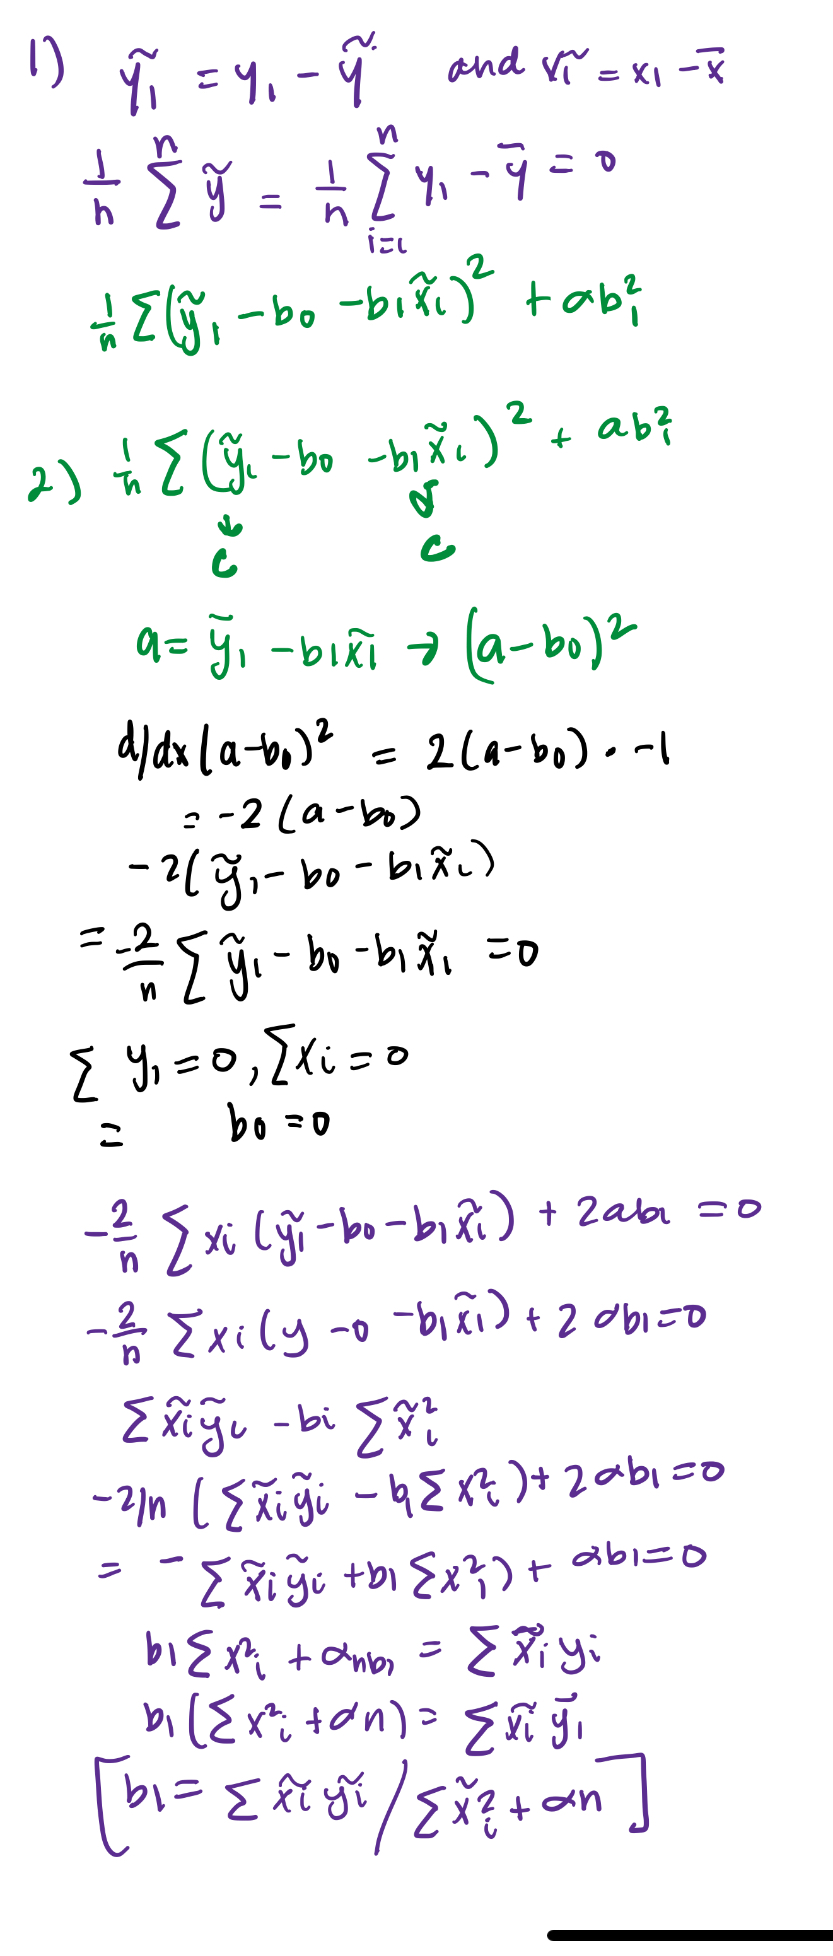

